In [1]:
# Setup — all imports live here so the notebook executes top-to-bottom
# without reimporting mid-notebook. When running headlessly (CI, HPC),
# uncomment the ``matplotlib.use('Agg')`` line *before* the pyplot import
# so figures never need an interactive display.
import dataclasses
import logging
import os
import sys
from collections import Counter
from pathlib import Path

# import matplotlib
# matplotlib.use('Agg')  # enable for headless runs
import matplotlib.pyplot as plt
import mne
import numpy as np
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap
from mne.viz import plot_topomap
from scipy.sparse.csgraph import connected_components
from scipy.stats import pearsonr

# Resolve project root regardless of where the notebook is launched from
for _candidate in [".", "..", "../.."]:  # noqa: B007
    _p = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, _p)
        break

from independent_vector_analysis import iva_g  # noqa: E402
from sklearn.decomposition import PCA  # noqa: E402

from scripts.analysis_common import (  # noqa: E402
    FREQUENCY_BANDS,
    WAVELET_BAND_FREQ_RESOLUTION_HZ,
    analyzers_to_datasets,
    load_analyzers,
    wavelet_transform,
)
from src.analysis.wavelet_ica import zscore_by_time  # noqa: E402
from src.definitions.constants import ProjectPaths  # noqa: E402
from src.definitions.fields import (  # noqa: E402
    ConditionVariants,
    ExclusionCategories,
    MusicTypeVariants,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


# IVA Decomposition of Wavelet Power

## Scope

Run the **Independent Vector Analysis** algorithm on the 4-D wavelet
power tensor and stop. Analyses of the resulting sources / mixing
matrices live in companion notebooks (next steps).

Unlike single-dataset ICA, **IVA decomposes K datasets jointly** while
preserving the dependency between corresponding sources across
datasets. Here each **subject is one dataset**, so IVA yields a set
of components that are *already aligned* across subjects — the kth
source in subject 1 corresponds to the kth source in subjects 2..K.
This removes the permutation ambiguity that single-subject ICA
introduces and is the main motivation for choosing IVA over ICA in a
group analysis.

## Reshape

Each subject's wavelet tensor is flattened so that **channels ×
frequencies** form the observation axis and **time** is the sample
axis:

```
Input:   (n_subjects, n_channels, n_freqs, n_times)
Per-subject reshape:
         (n_channels, n_freqs, n_times)
         → (n_channels × n_freqs,  n_times)
           ──── features ──────   samples
Stack:   (n_pca,  n_times,  n_subjects)  — IVA input layout (N, T, K)
```

IVA-G requires a **square** mixing matrix per dataset (`N == feature
dim`), so each subject's `(C×F, T)` matrix is first reduced with a
**per-subject PCA** to `N_PCA` components before stacking.

## Pipeline

1. Load wavelet power for the chosen condition / music type (cached).
2. Apply subject / channel / time subsets for fast iteration.
3. Z-score along time.
4. Per-subject reshape to `(C×F, T)` and per-subject PCA to `N_PCA`.
5. Stack into `(N_PCA, T, K)` and run **IVA-G**.
6. Recover per-subject sources and per-subject component patterns in
   the original `(F, C)` feature space.

After the final cell the following variables are available for any
downstream analysis notebook:

| Variable | Shape | Description |
|----------|-------|-------------|
| `bb_data` | `(S, C, F, T)` | Raw 4-D wavelet power tensor |
| `bb_z` | `(S, C, F, T)` | Z-scored 4-D wavelet power tensor |
| `X_subjects` | `(S, C×F, T)` | Per-subject z-scored reshape |
| `pcas` | list[`PCA`] | Per-subject fitted PCA objects |
| `X_pca` | `(N_PCA, T, S)` | PCA-reduced IVA input layout |
| `W` | `(N_PCA, N_PCA, S)` | Per-subject IVA demixing matrices |
| `cost` | `(n_iter,)` | IVA cost per iteration |
| `iva_sources_pca` | `(S, N_PCA, T)` | Per-subject IVA sources in PCA space |
| `iva_components` | `(S, N_PCA, F, C)` | IVA component patterns reshaped to (freq, channel) per subject |

## Configuration

In [2]:
# ── Experiment configuration ───────────────────────────────────
CONDITION = ConditionVariants.PLACEBO
MUSIC_TYPES = [MusicTypeVariants.CLASSICAL]  # single type for fast exploration
EXCLUSION_CATEGORIES = [ExclusionCategories.BAD_MUSIC, ExclusionCategories.ARTIFACTS]
PROCESS_AND_SAVE_DATA = False  # set True to re-process raw files

# ── Wavelet settings ─────────────────────────────────────────
REPRESENTATION = "power"
WAVELET_FREQ_MIN = min(lo for lo, _ in FREQUENCY_BANDS.values())
WAVELET_FREQ_MAX = max(hi for _, hi in FREQUENCY_BANDS.values())
WAVELET_N_FREQS = max(
    2,
    int(round((WAVELET_FREQ_MAX - WAVELET_FREQ_MIN) / WAVELET_BAND_FREQ_RESOLUTION_HZ))
    + 1,
)
FREQS = np.linspace(WAVELET_FREQ_MIN, WAVELET_FREQ_MAX, WAVELET_N_FREQS)

KEEP_FREQUENCY_DIM = True
RESHAPE_FREQUENCY_DIM = True  # -> (n_subjects, n_channels, n_freqs, n_times)

# ── Reuse / compute ──────────────────────────────────────────
REUSE_WAVELETS = True  # load from cache; set False to compute + save

# ── Subject subset ────────────────────────────────────────────
N_SUBJECTS_SUBSET: int | None = 5

# ── Channel and time subset ─────────────────────────────────────
N_CHANNELS_SUBSET: int | None = 32  # first N channels (from 195)
N_TIMES_SUBSET: int | None = 10000  # first N time samples

# ── IVA settings ──────────────────────────────────────────────
N_COMPONENTS_PCA = 50  # per-subject PCA dim before IVA (= N in IVA's (N, T, K))
IVA_OPT_APPROACH = "newton"  # 'gradient', 'newton', or 'quasi'
IVA_MAX_ITER = 1024
IVA_W_DIFF_STOP = 1e-6
IVA_VERBOSE = True
IVA_RANDOM_STATE = 42  # seeds per-subject PCA + W_init

# ── Storage directory ─────────────────────────────────────────
# Mirror the 04 cache so wavelets are not recomputed when iterating on IVA.
WAVELET_DIR: Path = (
    ProjectPaths.NOTEBOOKS_DIR / "04-wavelet-ica-analysis" / "wavelet_cache"
)

# ── Downstream analysis settings ──────────────────────────────
N_COMPONENTS_SHOW = 10  # number of IVA components to visualise downstream
SAVE_PLOTS = True
PLOTS_DIR = (
    ProjectPaths.NOTEBOOKS_DIR
    / "05-wavelet-iva-analysis"
    / "plots"
    / "broadband"
    / "iva"
)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Wavelet base directory : {WAVELET_DIR}")
print(f"Plots directory        : {PLOTS_DIR}")
print(
    f"Frequencies            : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz ({len(FREQS)} steps)"
)
print(f"Per-subject PCA dim    : {N_COMPONENTS_PCA}")
print(f"IVA optimisation       : {IVA_OPT_APPROACH}")
print(f"Components to show     : {N_COMPONENTS_SHOW}")

Wavelet base directory : /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache
Plots directory        : /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/05-wavelet-iva-analysis/plots/broadband/iva
Frequencies            : 1.0–70.0 Hz (70 steps)
Per-subject PCA dim    : 50
IVA optimisation       : newton
Components to show     : 10


## Data Loading

In [3]:
analyzers = load_analyzers(
    MUSIC_TYPES,
    CONDITION,
    EXCLUSION_CATEGORIES,
    PROCESS_AND_SAVE_DATA,
    normalize_data=False,
)
datasets = analyzers_to_datasets(analyzers)

# Always limit to first N_SUBJECTS_SUBSET individuals
if N_SUBJECTS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:N_SUBJECTS_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_SUBJECTS_SUBSET} individuals.")

# Slice to channel subset
if N_CHANNELS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :N_CHANNELS_SUBSET, :])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_CHANNELS_SUBSET} channels.")

# Slice to time subset
if N_TIMES_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :, :N_TIMES_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_TIMES_SUBSET} time samples.")

print("Loaded datasets:", list(datasets.keys()))
for label, ad in datasets.items():
    print(
        f"  {label}: {ad.n_items} subjects, {ad.n_features} channels, "
        f"{ad.n_samples} samples"
    )

INFO src.analysis.summary.EEGSummarizedAnalyzer: Data loaded from /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/concatenated/Placebo_CLASSIC.npy  (shape=(15, 195, 91392))


Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif...


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/src/io/loading.py:110: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


    Range : 19254 ... 384821 =     19.254 ...   384.821 secs
Ready.


INFO scripts.analysis_common: [Placebo_CLASSIC] Loaded data shape: (15, 195, 91392)
INFO scripts.analysis_common: [Placebo_CLASSIC] AnalysisData('Placebo_CLASSIC', time_domain, 15 items × 195 features × 91392 samples, sfreq=250.0)


Using first 5 individuals.
Using first 32 channels.
Using first 10000 time samples.
Loaded datasets: ['Placebo_CLASSIC']
  Placebo_CLASSIC: 5 subjects, 32 channels, 10000 samples


## Load or Compute Wavelet Transforms

Stored in `WAVELET_DIR/broadband/` (shared with the 04 ICA notebooks).

In [4]:
broadband_datasets = wavelet_transform(
    datasets=datasets,
    freqs=FREQS,
    representation=REPRESENTATION,
    keep_frequency_dim=KEEP_FREQUENCY_DIM,
    reshape_frequency_dim=RESHAPE_FREQUENCY_DIM,
    wavelet_dir=WAVELET_DIR / "broadband",
    reuse_wavelets=REUSE_WAVELETS,
)
for label, ad in broadband_datasets.items():
    source = ad.metadata.get("loaded_from_wavelet_file", "computed_now")
    print(f"[broadband] {label}: shape={ad.data.shape}  source={source}")

[broadband] Placebo_CLASSIC: shape=(5, 32, 70, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache/broadband/Placebo_CLASSIC__wavelet_power__1.000_70.000_70__freqdim1.npz


## Dataset Selection

Change `LABEL` to switch between music types. The remaining cells use
`bb_data` (broadband wavelet power, 4-D) and derived quantities.

In [5]:
LABEL = list(broadband_datasets.keys())[0]

bb_ad = broadband_datasets[LABEL]
bb_data = bb_ad.data  # (n_subjects, n_channels, n_freqs, n_times)
sfreq = bb_ad.sfreq

n_subjects, n_channels, n_freqs, n_times = bb_data.shape
time = np.arange(n_times) / sfreq

print(f"Dataset    : {LABEL}")
print(f"Shape      : {bb_data.shape}  (subjects × channels × freqs × times)")
print(f"Duration   : {n_times / sfreq:.1f} s  @  {sfreq} Hz")
print(f"Freq range : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz ({n_freqs} steps)")

Dataset    : Placebo_CLASSIC
Shape      : (5, 32, 70, 10000)  (subjects × channels × freqs × times)
Duration   : 40.0 s  @  250.0 Hz
Freq range : 1.0–70.0 Hz (70 steps)


---
## Step 1 — Z-score and Per-Subject Reshape

**Z-scoring** normalises each `(subject, channel, frequency)` time
series to zero mean and unit variance so that IVA is not dominated by
high-power channels, subjects, or frequencies.

**Reshape** is done independently per subject: for each subject `k`
the `(C, F, T)` slice becomes a `(C×F, T)` matrix — channels and
frequencies form the observation axis, time stays as samples. The
result is stacked as a `(S, C×F, T)` array (Python view; IVA wants
axis-ordering `(N, T, K)` which we build in the next step).

| Quantity | Shape | Description |
|----------|-------|-------------|
| `bb_z` | `(S, C, F, T)` | Z-scored wavelet power |
| `X_subjects` | `(S, C×F, T)` | Per-subject z-scored reshape |

In [6]:
# Z-score along time: each (subject, channel, frequency) slice → mean=0, std=1
bb_z = zscore_by_time(bb_data)  # (S, C, F, T)

# Per-subject reshape: (S, C, F, T) → (S, C*F, T)
n_feat = n_channels * n_freqs
X_subjects = bb_z.reshape(n_subjects, n_feat, n_times)  # (S, C*F, T)

print(f"Per-subject reshape    : {X_subjects.shape}  (subjects, C*F, time)")
print(f"  Features per subject : {n_feat}  (C={n_channels} * F={n_freqs})")
print(f"  Samples per subject  : {n_times}")

Per-subject reshape    : (5, 2240, 10000)  (subjects, C*F, time)
  Features per subject : 2240  (C=32 * F=70)
  Samples per subject  : 10000


---
## Step 2 — Per-Subject PCA Dimensionality Reduction

`iva_g` assumes a **square** mixing matrix per dataset, i.e. the
number of estimated sources equals the input dimensionality. Running
IVA directly on `(C×F)` features per subject would be prohibitively
expensive (and rank-deficient if `C×F > T`). Each subject's matrix
is reduced with its **own** PCA to `N_PCA` components, after which the
K subject matrices are stacked into IVA's `(N, T, K)` layout.

Keeping per-subject PCAs (rather than a single shared PCA) preserves
subject-specific spatial / spectral subspaces, which is exactly what
IVA exploits to align cross-subject sources.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `pcas[k]` | — | Fitted PCA object for subject `k` |
| `pca_evr` | `(S, N_PCA)` | Explained-variance ratio per subject |
| `X_pca` | `(N_PCA, T, S)` | IVA input layout (N, T, K) |

  S1: explained variance =  79.9% (50 comps)
  S2: explained variance =  75.8% (50 comps)
  S3: explained variance =  70.5% (50 comps)
  S4: explained variance =  65.9% (50 comps)
  S5: explained variance =  74.9% (50 comps)

IVA input shape        : (50, 10000, 5)  (N_PCA, T, K=subjects)


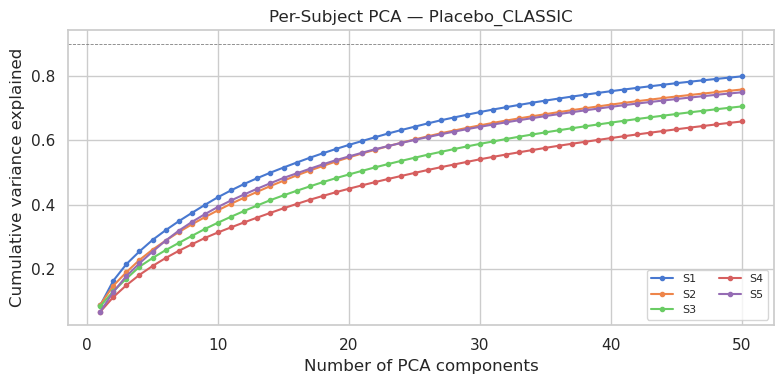

In [7]:
# Per-subject PCA. PCA expects (n_samples, n_features); each subject's matrix
# is (C*F, T) → transpose to (T, C*F), fit, transform back to (T, N_PCA),
# transpose to (N_PCA, T), then stack along axis 2 as IVA expects.
pcas: list[PCA] = []
pca_scores_per_subject = np.zeros((n_subjects, N_COMPONENTS_PCA, n_times))
pca_evr = np.zeros((n_subjects, N_COMPONENTS_PCA))

for k in range(n_subjects):
    subj_matrix = X_subjects[k].T  # (T, C*F) — samples x features for sklearn
    pca = PCA(n_components=N_COMPONENTS_PCA, random_state=IVA_RANDOM_STATE)
    scores = pca.fit_transform(subj_matrix)  # (T, N_PCA)
    pcas.append(pca)
    pca_scores_per_subject[k] = scores.T  # (N_PCA, T)
    pca_evr[k] = pca.explained_variance_ratio_
    print(
        f"  S{k + 1}: explained variance = {pca_evr[k].sum() * 100:5.1f}% "
        f"({N_COMPONENTS_PCA} comps)"
    )

# IVA expects (N, T, K)
X_pca = np.ascontiguousarray(pca_scores_per_subject.transpose(1, 2, 0))

print(f"\nIVA input shape        : {X_pca.shape}  (N_PCA, T, K=subjects)")

# Quick visual of how much variance each subject's PCA retains.
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(n_subjects):
    ax.plot(
        np.arange(1, N_COMPONENTS_PCA + 1),
        np.cumsum(pca_evr[k]),
        marker="o",
        markersize=3,
        label=f"S{k + 1}",
    )
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative variance explained")
ax.set_title(f"Per-Subject PCA — {LABEL}")
ax.legend(fontsize=8, ncol=2)
ax.axhline(0.9, ls="--", lw=0.6, color="gray")
fig.tight_layout()
plt.show()
plt.close("all")

---
## Step 3 — Run IVA-G

`iva_g` returns a demixing matrix `W` of shape `(N, N, K)`. The
sources for subject `k` are then

```
S_pca[k]  = W[:, :, k] @ X_pca[:, :, k]                 # (N_PCA, T)
S_full[k] = pcas[k].components_.T @ S_pca[k]             # (C*F, T)
components[k] = (W[:, :, k] @ pcas[k].components_)       # (N_PCA, C*F)
             .reshape(N_PCA, F, C)
```

Because IVA's permutation ambiguity is **shared across datasets**, the
kth source in `S_full[0]` corresponds to the kth source in
`S_full[1..K-1]` — there is no need to align sources across subjects
post-hoc.

| Returned by `iva_g` | Shape | Description |
|---------------------|-------|-------------|
| `W` | `(N_PCA, N_PCA, S)` | Per-subject demixing matrix |
| `cost` | `(n_iter,)` | IVA cost per iteration |
| `Sigma_N` | `(S, S, N_PCA)` | Per-source-component covariance across subjects |
| `isi` | `float` | Joint inter-symbol-interference (only when ground-truth `A` is given) |

Step 0: W change: 0.006357942219596624, Cost: 519.1378393250218
Step 1: W change: 0.014182534066498609, Cost: 353.0925462966301
Step 2: W change: 0.014350769051947654, Cost: 351.6872073175122
Step 3: W change: 0.01722061584381185, Cost: 349.6104438018574
Step 4: W change: 0.01669639679724999, Cost: 346.86573038039387
Step 5: W change: 0.01542963344126036, Cost: 343.8289441447421
Step 6: W change: 0.013699844961336138, Cost: 340.9179087200313
Step 7: W change: 0.014246003102122318, Cost: 338.35251076086206
Step 8: W change: 0.012742471215380413, Cost: 336.17768746051104
Step 9: W change: 0.010683830198077504, Cost: 334.3569827799529
Step 10: W change: 0.008842939119640625, Cost: 332.8360589546913
Step 11: W change: 0.008670209775045956, Cost: 331.56720024037435
Step 12: W change: 0.00800414064052446, Cost: 330.5087568902371
Step 13: W change: 0.006890103870988096, Cost: 329.62181973330854
Step 14: W change: 0.005641676725977707, Cost: 328.87133279541894
Step 15: W change: 0.004765652766

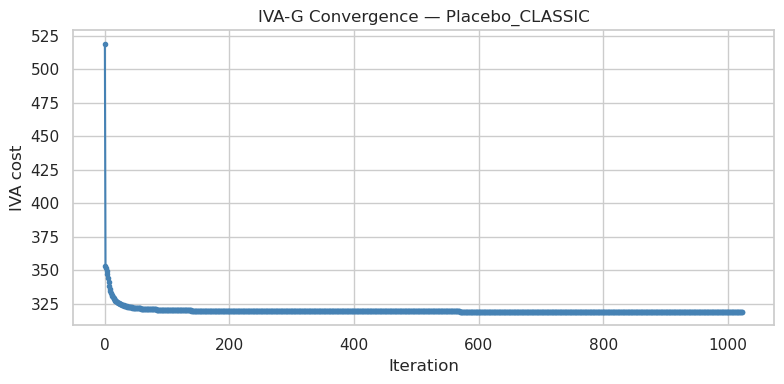

In [8]:
# Deterministic W initialisation: random matrix per subject seeded by IVA_RANDOM_STATE.
rng = np.random.default_rng(IVA_RANDOM_STATE)
W_init = rng.standard_normal((N_COMPONENTS_PCA, N_COMPONENTS_PCA, n_subjects))

W, cost, Sigma_N, isi = iva_g(
    X_pca,
    opt_approach=IVA_OPT_APPROACH,
    whiten=True,
    verbose=IVA_VERBOSE,
    W_init=W_init,
    max_iter=IVA_MAX_ITER,
    W_diff_stop=IVA_W_DIFF_STOP,
)

print(f"\nW shape           : {W.shape}  (N_PCA, N_PCA, K=subjects)")
print(f"Sigma_N shape     : {Sigma_N.shape}  (K, K, N_PCA)")
print(f"Iterations        : {len(cost)}")
print(f"Final cost        : {cost[-1]:.6f}")

# Cost-curve sanity check.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost, marker="o", markersize=3, color="steelblue")
ax.set_xlabel("Iteration")
ax.set_ylabel("IVA cost")
ax.set_title(f"IVA-G Convergence — {LABEL}")
fig.tight_layout()
plt.show()
plt.close("all")

---
## Step 4 — Recover Sources and Component Patterns

Apply the per-subject demixing matrix to the PCA-reduced data to
obtain IVA sources, then combine `W_k` with the PCA loadings to
express each component pattern over the original `(F, C)` axes
(directly comparable to `components_2d` in the 04 ICA notebook).

The kth row of `iva_components[k]` is the unmixing vector for the
kth source in subject `k`'s original feature space. Because IVA
resolves the permutation jointly across datasets, the kth row is
**already aligned** across subjects.

In [9]:
iva_sources_pca = np.zeros((n_subjects, N_COMPONENTS_PCA, n_times))
iva_components = np.zeros((n_subjects, N_COMPONENTS_PCA, n_freqs, n_channels))

for k in range(n_subjects):
    W_k = W[:, :, k]  # (N_PCA, N_PCA)
    X_pca_k = X_pca[:, :, k]  # (N_PCA, T)

    # Sources in the PCA subspace: (N_PCA, T)
    iva_sources_pca[k] = W_k @ X_pca_k

    # Project the unmixing rows back through the per-subject PCA loadings to
    # express component patterns in the full (C*F) feature space.
    components_full = W_k @ pcas[k].components_  # (N_PCA, C*F)

    # X_subjects was reshape (S, C, F, T) → (S, C*F, T), so the flattened axis
    # iterates channels (slow) then frequencies (fast). Reshape back to
    # (N_PCA, C, F) and transpose to (N_PCA, F, C) to mirror the 04 ICA
    # notebook's components_2d layout.
    iva_components[k] = components_full.reshape(
        N_COMPONENTS_PCA, n_channels, n_freqs
    ).transpose(0, 2, 1)

print(f"IVA sources (PCA space)  : {iva_sources_pca.shape}   (S, N_PCA, T)")
print(f"IVA components (F, C)    : {iva_components.shape}    (S, N_PCA, F, C)")

IVA sources (PCA space)  : (5, 50, 10000)   (S, N_PCA, T)
IVA components (F, C)    : (5, 50, 70, 32)    (S, N_PCA, F, C)


---
## Result Summary

All variables required for downstream analyses are now in memory:

| Variable | Shape | Description |
|----------|-------|-------------|
| `bb_data` | `(S, C, F, T)` | Raw 4-D wavelet power tensor |
| `bb_z` | `(S, C, F, T)` | Z-scored wavelet power tensor |
| `X_subjects` | `(S, C×F, T)` | Per-subject z-scored reshape |
| `pcas` | list[`PCA`] | Per-subject fitted PCA objects |
| `pca_evr` | `(S, N_PCA)` | Per-subject PCA explained-variance ratio |
| `X_pca` | `(N_PCA, T, S)` | IVA input (PCA-reduced) |
| `W` | `(N_PCA, N_PCA, S)` | Per-subject IVA demixing |
| `Sigma_N` | `(S, S, N_PCA)` | Per-SCV covariance across subjects |
| `cost` | `(n_iter,)` | IVA convergence trace |
| `iva_sources_pca` | `(S, N_PCA, T)` | Sources in PCA subspace |
| `iva_components` | `(S, N_PCA, F, C)` | Component patterns reshaped to (freq, channel) |

The kth source/component is **aligned across subjects** by
construction — no post-hoc matching is required. Downstream
notebooks can now compute ISC, topomaps, frequency profiles, etc.
on top of these variables.

# Downstream Analyses

The remaining cells operate on the IVA results above. They mirror the
plots in the companion ICA notebook
(`04-wavelet-ica-analysis/wavelet_ica_frequency_channel.ipynb`) but use
the IVA layout:

- **Sources** live in `iva_sources_pca` with shape `(S, N_PCA, T)` —
  the kth source is **already aligned** across subjects, so the
  natural ISC vector for component `k` is the per-subject row
  `iva_sources_pca[s, k, :]`.
- **Patterns** live in `iva_components` with shape `(S, N_PCA, F, C)`
  — every subject has their own spatial / spectral fingerprint for
  the same source index.

Each downstream plot shows the **first `N_COMPONENTS_SHOW = 10`
components**, and all plots are saved into `PLOTS_DIR` (canonical
`notebooks/05-wavelet-iva-analysis/plots/broadband/iva/`).

---
## Analysis (a) — PCA Scree Plot

IVA uses **per-subject PCA** (cell `iva-13-pca`) to reduce the
`(C × F)` feature space before joint decomposition, so the scree plot
summarises explained variance across **all subjects**:

- **Left bar plot**: across-subject mean of
  `explained_variance_ratio_` per component, with std as error bars.
- **Right line plot**: per-subject cumulative variance (gray, thin) +
  across-subject mean cumulative (coral) with a 90 % reference.

The red dashed line marks the cutoff at `N_COMPONENTS_SHOW`, the
number of components used in the downstream analyses below.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `pca_evr_mean` | `(N_PCA,)` | Mean explained variance ratio across subjects |
| `pca_evr_std` | `(N_PCA,)` | Std of explained variance ratio across subjects |
| `pca_evr_cum_mean` | `(N_PCA,)` | Mean cumulative explained variance |

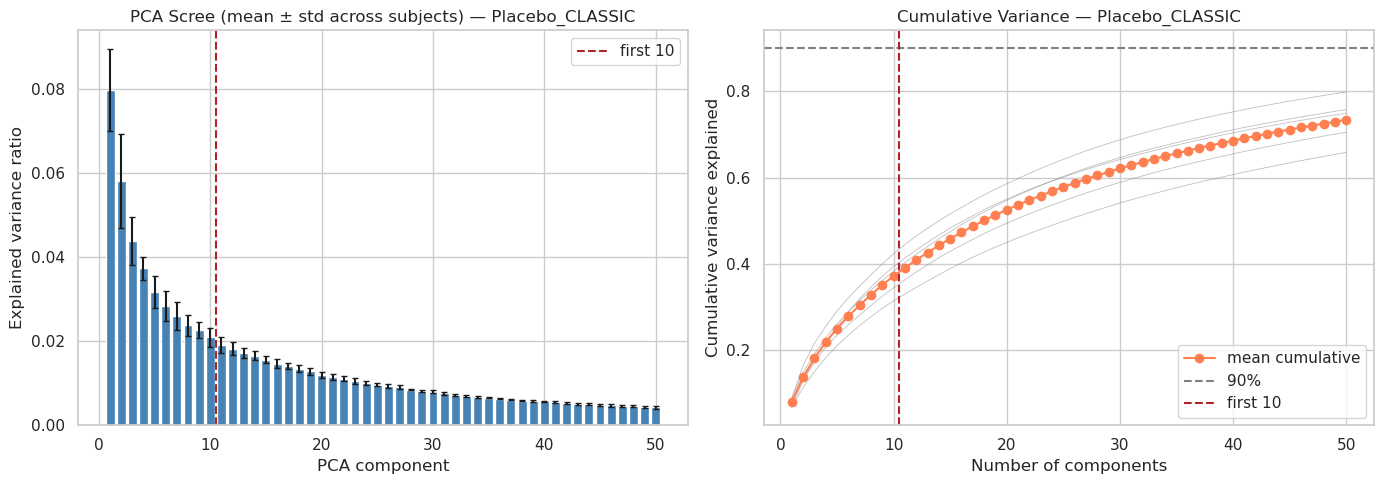

First 10 components explain 37.2% of variance on average.


In [10]:
# Across-subject summary of per-subject PCA explained-variance ratios.
pca_evr_mean = pca_evr.mean(axis=0)  # (N_PCA,)
pca_evr_std = pca_evr.std(axis=0)  # (N_PCA,)
pca_evr_cum_mean = np.cumsum(pca_evr_mean)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xs = np.arange(1, N_COMPONENTS_PCA + 1)
axes[0].bar(xs, pca_evr_mean, yerr=pca_evr_std, color="steelblue", capsize=2)
axes[0].axvline(
    N_COMPONENTS_SHOW + 0.5,
    ls="--",
    color="firebrick",
    label=f"first {N_COMPONENTS_SHOW}",
)
axes[0].set_xlabel("PCA component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title(f"PCA Scree (mean ± std across subjects) — {LABEL}")
axes[0].legend()

for k in range(n_subjects):
    axes[1].plot(xs, np.cumsum(pca_evr[k]), lw=0.6, alpha=0.5, color="gray")
axes[1].plot(xs, pca_evr_cum_mean, "o-", color="coral", label="mean cumulative")
axes[1].axhline(0.9, ls="--", color="gray", label="90%")
axes[1].axvline(
    N_COMPONENTS_SHOW + 0.5,
    ls="--",
    color="firebrick",
    label=f"first {N_COMPONENTS_SHOW}",
)
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance explained")
axes[1].set_title(f"Cumulative Variance — {LABEL}")
axes[1].legend()

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

print(
    f"First {N_COMPONENTS_SHOW} components explain "
    f"{pca_evr_cum_mean[N_COMPONENTS_SHOW - 1] * 100:.1f}% of variance on average."
)

---
## Analysis (b) — Intersubject Correlation of IVA Source Timecourses

For each IVA component the **per-subject source timecourse** is the
length-`T` row `iva_sources_pca[s, k, :]`. We build a subject ×
subject Pearson correlation matrix per component. Because IVA aligns
the kth source across subjects by construction, high off-diagonal
correlations indicate a temporally consistent activation pattern.

A **cluster strip** beneath each correlation matrix colors subjects by
connected-component membership at each ISC threshold (`r ≥ 0.3, 0.5,
0.7`). Singletons stay gray; group IDs disambiguate clusters within a
row.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `source_corr_per_comp` | `(N_SHOW, S, S)` | Per-IC subject×subject source correlation |

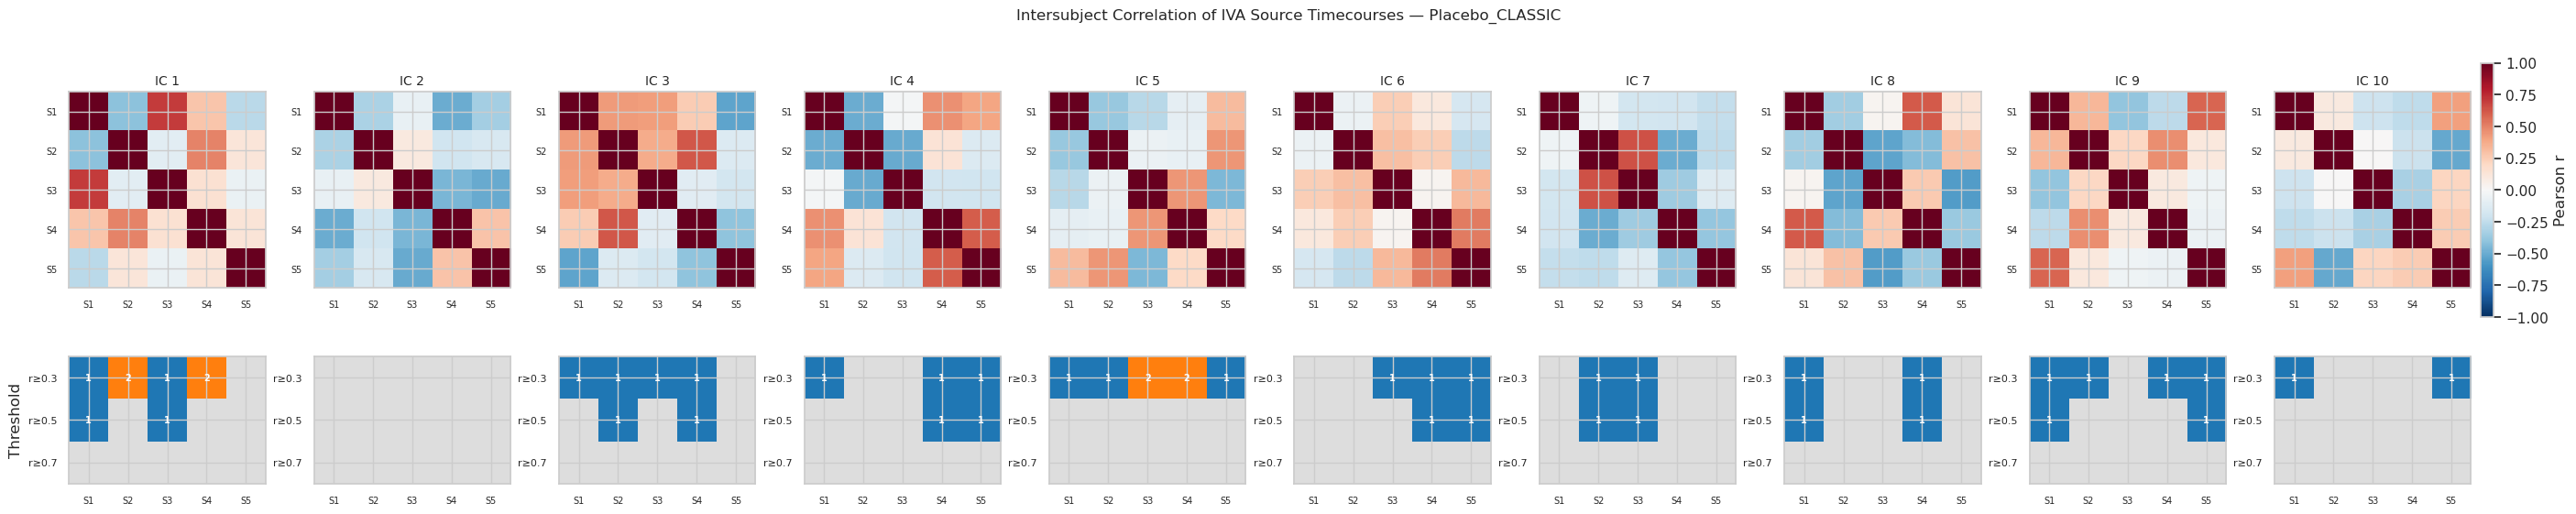

In [11]:
# Pearson-r thresholds used for the cluster strip below each ISC matrix.
ISC_CLUSTER_THRESHOLDS = (0.3, 0.5, 0.7)

# Discrete colormap: light gray for singletons (0) + tab10 for groups (1..10).
_GROUP_PALETTE = list(plt.colormaps["tab10"].colors)
_CLUSTER_CMAP = ListedColormap(["#dddddd"] + _GROUP_PALETTE)
_CLUSTER_NORM = BoundaryNorm(
    np.arange(-0.5, len(_GROUP_PALETTE) + 1.5, 1.0), _CLUSTER_CMAP.N
)


def _cluster_grid(
    corr_mat: np.ndarray, thresholds=ISC_CLUSTER_THRESHOLDS
) -> np.ndarray:
    """(T, S) grid of within-row cluster IDs. Singletons → 0, groups → 1, 2, ...."""
    grid = np.zeros((len(thresholds), n_subjects), dtype=int)
    for t_idx, thr in enumerate(thresholds):
        adj = (corr_mat >= thr) & ~np.eye(n_subjects, dtype=bool)
        _, labels = connected_components(adj, directed=False)
        counts = Counter(labels.tolist())
        next_group = 1
        group_map: dict[int, int] = {}
        for s in range(n_subjects):
            lab = int(labels[s])
            if counts[lab] == 1:
                grid[t_idx, s] = 0
            else:
                if lab not in group_map:
                    group_map[lab] = next_group
                    next_group += 1
                grid[t_idx, s] = group_map[lab]
    return grid


def _plot_isc_grid(corr_per_comp, fig_title, file_name):
    """Plot ISC correlation matrices + cluster strips for the first N components."""
    n_show = N_COMPONENTS_SHOW
    fig, axes = plt.subplots(
        2,
        n_show,
        figsize=(2.8 * n_show, 5.5),
        gridspec_kw={"height_ratios": [3, 1.2]},
        constrained_layout=True,
    )
    if n_show == 1:
        axes = axes.reshape(2, 1)

    im_corr = None
    for i in range(n_show):
        corr_mat = corr_per_comp[i]
        ax_top = axes[0, i]
        im_corr = ax_top.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdBu_r")
        ax_top.set_xticks(range(n_subjects))
        ax_top.set_yticks(range(n_subjects))
        ax_top.set_xticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=7)
        ax_top.set_yticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=7)
        ax_top.set_title(f"IC {i + 1}", fontsize=10)

        ax_bot = axes[1, i]
        grid = _cluster_grid(corr_mat)
        ax_bot.imshow(grid, cmap=_CLUSTER_CMAP, norm=_CLUSTER_NORM, aspect="auto")
        for ti in range(grid.shape[0]):
            for sj in range(grid.shape[1]):
                val = int(grid[ti, sj])
                if val > 0:
                    ax_bot.text(
                        sj,
                        ti,
                        str(val),
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="white",
                        weight="bold",
                    )
        ax_bot.set_xticks(range(n_subjects))
        ax_bot.set_xticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=7)
        ax_bot.set_yticks(range(len(ISC_CLUSTER_THRESHOLDS)))
        ax_bot.set_yticklabels(
            [f"r≥{thr}" for thr in ISC_CLUSTER_THRESHOLDS], fontsize=8
        )
        if i == 0:
            ax_bot.set_ylabel("Threshold")

    fig.suptitle(fig_title, fontsize=12)
    fig.colorbar(im_corr, ax=axes[0, -1], label="Pearson r", shrink=0.8)
    if SAVE_PLOTS:
        fig.savefig(PLOTS_DIR / file_name, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close("all")


# Subject × subject correlations of source timecourses, per component.
source_corr_per_comp = np.stack(
    [np.corrcoef(iva_sources_pca[:, k, :]) for k in range(N_COMPONENTS_SHOW)]
)  # (N_SHOW, S, S)

_plot_isc_grid(
    source_corr_per_comp,
    fig_title=f"Intersubject Correlation of IVA Source Timecourses — {LABEL}",
    file_name="iva_source_isc_matrix.png",
)

---
## Analysis (c) — Intersubject Correlation of IVA Component Patterns

The same idea as (b), but applied to the **spatial / spectral pattern**
of each component rather than its timecourse. For each component `k`
the per-subject feature is the flattened `(F × C)` pattern
`iva_components[s, k].ravel()`. Pearson correlations across subjects
quantify whether the kth component lands on similar channel /
frequency loadings across individuals — complementary to the source
timecourse alignment IVA enforces by construction.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `pattern_corr_per_comp` | `(N_SHOW, S, S)` | Per-IC subject×subject pattern correlation |

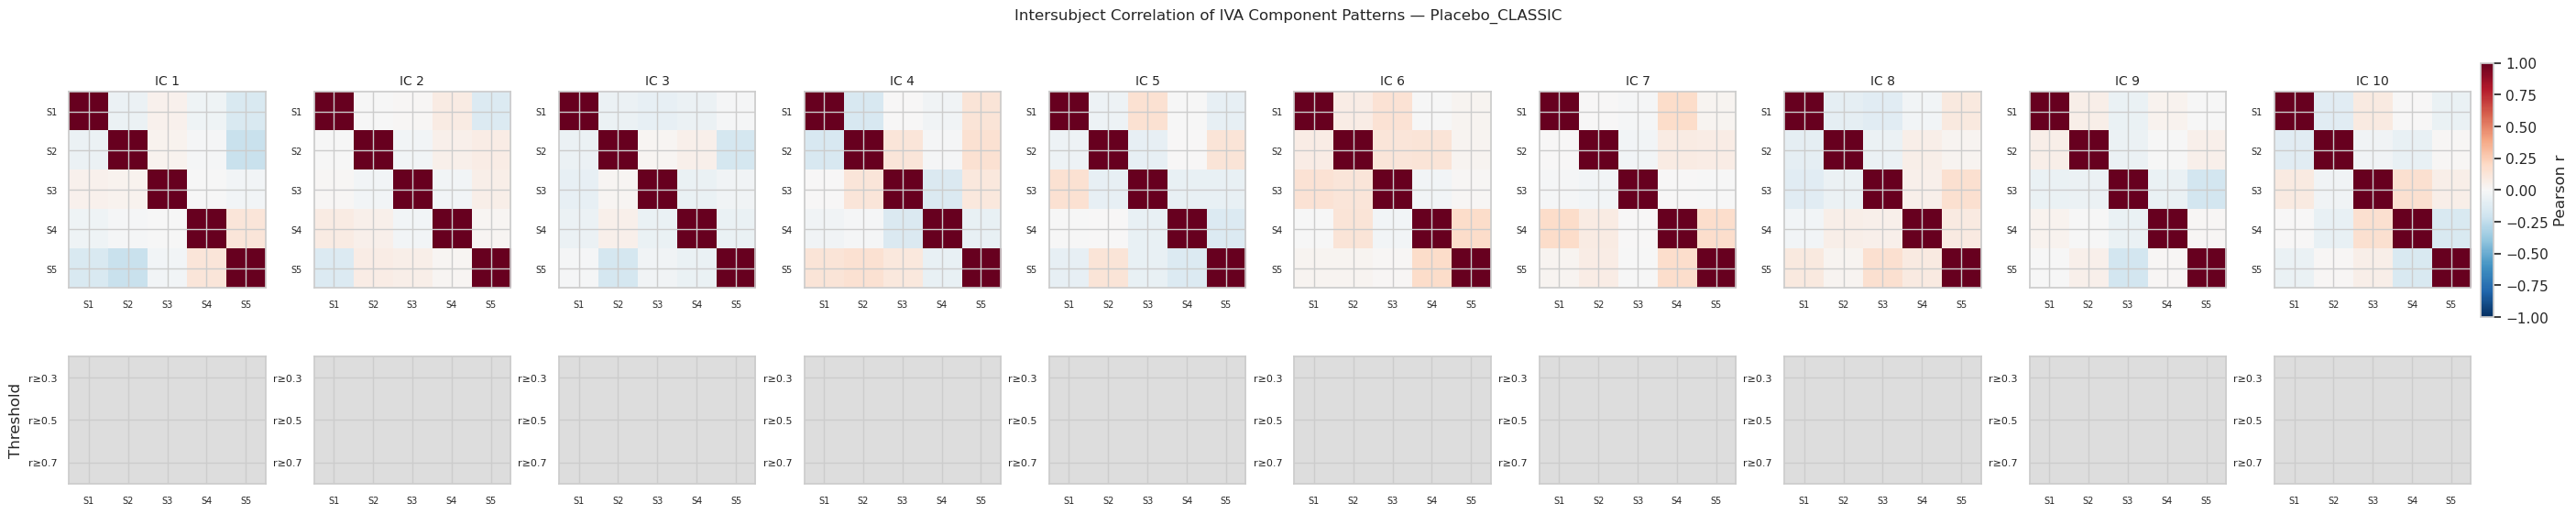

In [12]:
# Subject × subject correlations of component (F, C) patterns, per IC.
# Each subject's pattern is iva_components[s, k] of shape (F, C),
# flattened to a length-(F*C) vector.
pattern_corr_per_comp = np.zeros((N_COMPONENTS_SHOW, n_subjects, n_subjects))
for k in range(N_COMPONENTS_SHOW):
    flat_patterns = iva_components[:, k, :, :].reshape(n_subjects, -1)  # (S, F*C)
    pattern_corr_per_comp[k] = np.corrcoef(flat_patterns)

_plot_isc_grid(
    pattern_corr_per_comp,
    fig_title=f"Intersubject Correlation of IVA Component Patterns — {LABEL}",
    file_name="iva_pattern_isc_matrix.png",
)

---
## Analysis (d) — Mean LOO-ISC Across Participants per Component

Whole-recording leave-one-out inter-subject correlation per IVA
component. For each component `k`:

```
for each subject s:
    others_mean = mean over s' ≠ s of iva_sources_pca[s', k, :]
    r[k, s]     = pearson(iva_sources_pca[s, k, :], others_mean)
```

The bar height is the across-subject **mean** of `r[k, s]`; the error
bar is the across-subject **std**. Bars are red where the mean is
negative.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `loo_isc_per_subject` | `(N_SHOW, S)` | Whole-recording LOO-ISC per IC and subject |
| `loo_isc_mean` | `(N_SHOW,)` | Across-subject mean LOO-ISC per IC |
| `loo_isc_std` | `(N_SHOW,)` | Across-subject std LOO-ISC per IC |

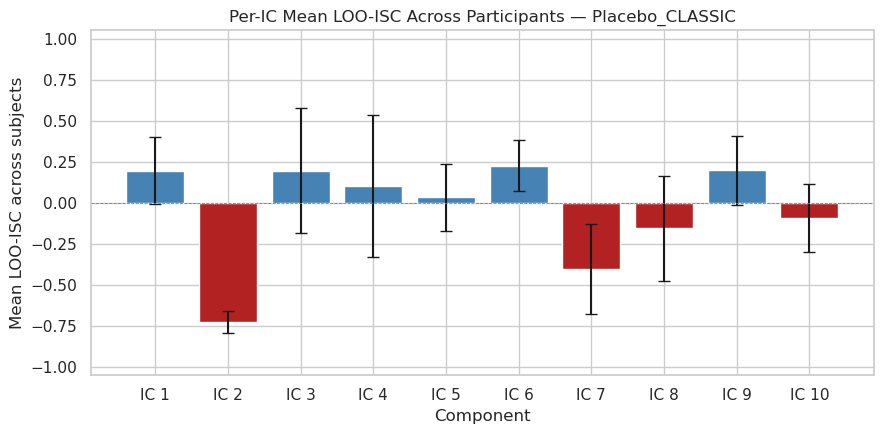

In [13]:
# Whole-recording LOO-ISC per component, using per-subject source timecourses.
loo_isc_per_subject = np.zeros((N_COMPONENTS_SHOW, n_subjects))
for k in range(N_COMPONENTS_SHOW):
    subj_vectors = iva_sources_pca[:, k, :]  # (S, T)
    for s in range(n_subjects):
        others_mean = np.delete(subj_vectors, s, axis=0).mean(axis=0)
        loo_isc_per_subject[k, s] = float(pearsonr(subj_vectors[s], others_mean)[0])

loo_isc_mean = loo_isc_per_subject.mean(axis=1)
loo_isc_std = loo_isc_per_subject.std(axis=1)

bar_colors = ["firebrick" if m < 0 else "steelblue" for m in loo_isc_mean]

fig, ax = plt.subplots(figsize=(max(8, 0.9 * N_COMPONENTS_SHOW), 4.5))
xs = np.arange(N_COMPONENTS_SHOW)
ax.bar(xs, loo_isc_mean, yerr=loo_isc_std, color=bar_colors, capsize=4)
ax.axhline(0.0, ls="--", lw=0.6, color="gray")
ax.set_xticks(xs)
ax.set_xticklabels([f"IC {k + 1}" for k in range(N_COMPONENTS_SHOW)])
ax.set_xlabel("Component")
ax.set_ylabel("Mean LOO-ISC across subjects")
ax.set_ylim(-1.05, 1.05)
ax.set_title(f"Per-IC Mean LOO-ISC Across Participants — {LABEL}")

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "iva_loo_isc_bar.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (e) — Topomap of Mean and Variance Across Subjects

For every IVA component `k` each subject has their own `(F × C)`
pattern. Collapsing the frequency axis yields a per-subject
**channel loading** vector:

```
chan_loading[s, k, c] = mean over f of iva_components[s, k, f, c]
```

We then summarise the across-subject distribution per channel with
the **mean** and the **variance**, giving two topomaps per component:
the mean spatial fingerprint (`RdBu_r`, symmetric) and the
across-subject dispersion (`viridis`, non-negative).

| Quantity | Shape | Description |
|----------|-------|-------------|
| `chan_loading` | `(S, N_PCA, C)` | Per-subject channel loading per IC |
| `chan_mean` | `(N_PCA, C)` | Mean channel loading across subjects |
| `chan_var` | `(N_PCA, C)` | Variance of channel loading across subjects |

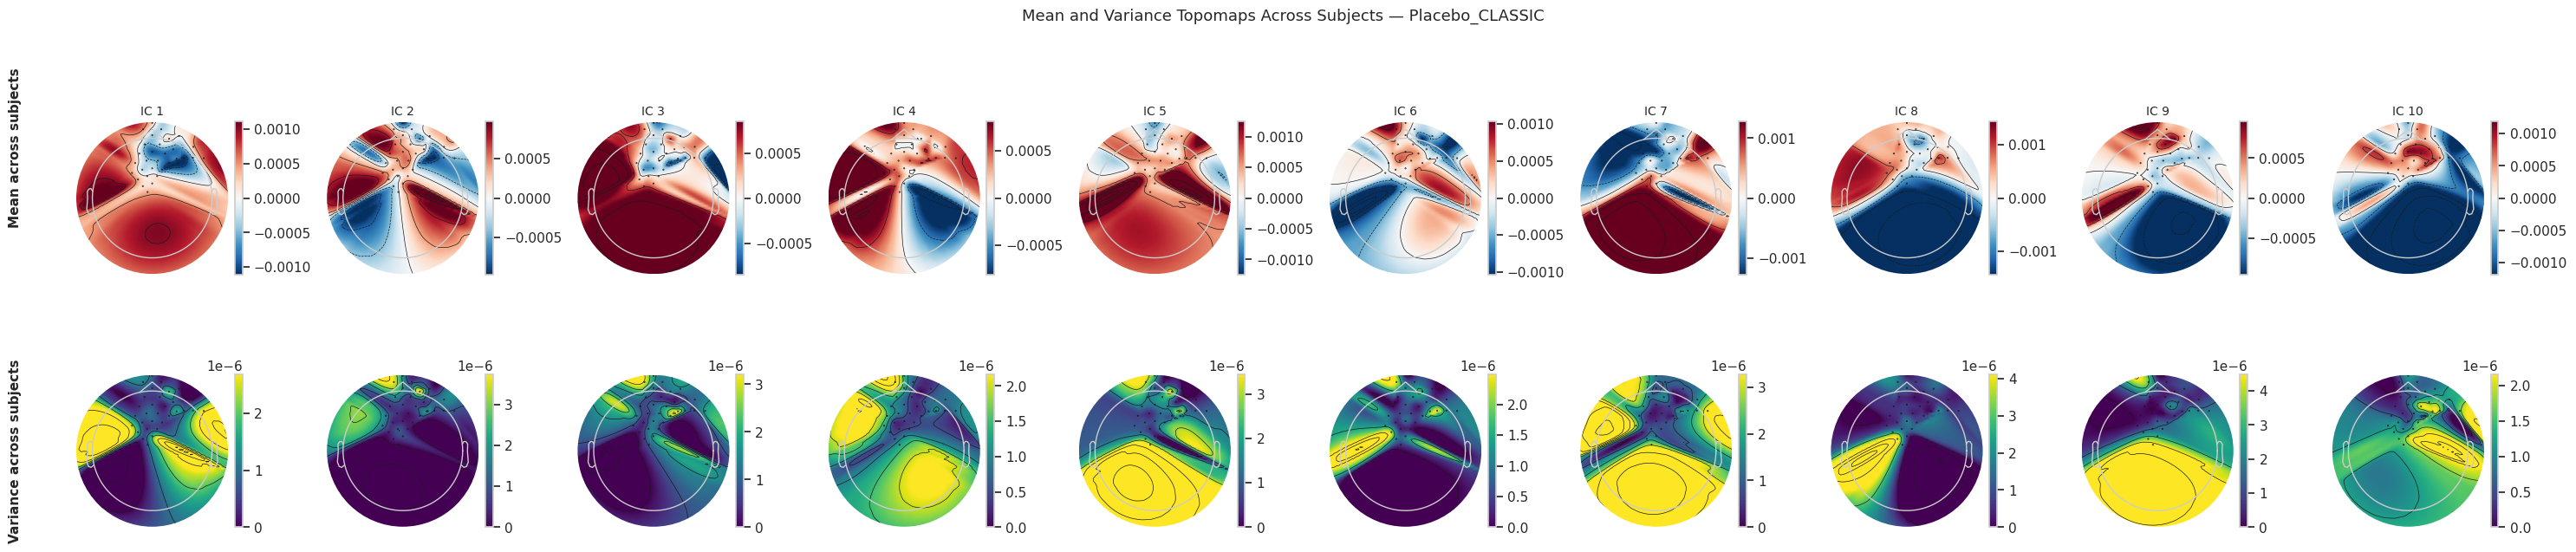

In [14]:
# Per-subject channel loading (collapse frequency axis): (S, N_PCA, C)
chan_loading = iva_components.mean(axis=2)
chan_mean = chan_loading.mean(axis=0)  # (N_PCA, C)
chan_var = chan_loading.var(axis=0)  # (N_PCA, C)

# MNE info for the topomap, restricted to the channel subset.
info = analyzers[LABEL].info
info = mne.pick_info(info, mne.pick_types(info, eeg=True))
if n_channels < len(info.ch_names):
    info = mne.pick_info(info, list(range(n_channels)))

n_show = N_COMPONENTS_SHOW
fig, axes = plt.subplots(2, n_show, figsize=(3.0 * n_show, 7.0))
if n_show == 1:
    axes = axes.reshape(2, 1)

for i in range(n_show):
    # Mean topomap (signed)
    vlim_m = float(np.percentile(np.abs(chan_mean[i]), 99))
    if vlim_m == 0.0:
        vlim_m = 1e-12
    im_m, _ = plot_topomap(
        chan_mean[i],
        info,
        axes=axes[0, i],
        show=False,
        cmap="RdBu_r",
        vlim=(-vlim_m, vlim_m),
    )
    axes[0, i].set_title(f"IC {i + 1}", fontsize=10)
    fig.colorbar(im_m, ax=axes[0, i], fraction=0.046, pad=0.04)

    # Variance topomap (non-negative)
    vlim_v = float(np.percentile(chan_var[i], 99))
    if vlim_v == 0.0:
        vlim_v = 1e-12
    im_v, _ = plot_topomap(
        chan_var[i],
        info,
        axes=axes[1, i],
        show=False,
        cmap="viridis",
        vlim=(0.0, vlim_v),
    )
    fig.colorbar(im_v, ax=axes[1, i], fraction=0.046, pad=0.04)

fig.text(
    0.01,
    0.75,
    "Mean across subjects",
    rotation=90,
    va="center",
    fontsize=11,
    fontweight="bold",
)
fig.text(
    0.01,
    0.25,
    "Variance across subjects",
    rotation=90,
    va="center",
    fontsize=11,
    fontweight="bold",
)
fig.suptitle(
    f"Mean and Variance Topomaps Across Subjects — {LABEL}",
    fontsize=13,
)
fig.tight_layout(rect=(0.03, 0, 1, 0.97))
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "iva_topomap_mean_var.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (f) — Time × Frequency Map per Component (Outer Product)

For each IVA component we summarise its time-frequency expression by
combining a **subject-averaged frequency profile** with a
**subject-averaged source timecourse** via outer product:

```
freq_profile[k] = iva_components.mean(axis=0)[k].mean(axis=1)    # (F,) channel-avg
time_profile[k] = iva_sources_pca.mean(axis=0)[k]                # (T,) subject-avg
tf_map[k]       = outer(freq_profile[k], time_profile[k])        # (F, T)
```

This is a rank-1 approximation of the component's `(F, T)` structure
grounded entirely in the IVA solution — channels are averaged out of
the patterns, and subjects are averaged out of both axes.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `freq_profiles` | `(F, N_PCA)` | Channel-averaged loading per frequency, per IC |
| `time_profiles` | `(N_PCA, T)` | Subject-averaged source timecourse per IC |
| `ft_maps` | `(N_PCA, F, T)` | Outer-product frequency × time map per component |

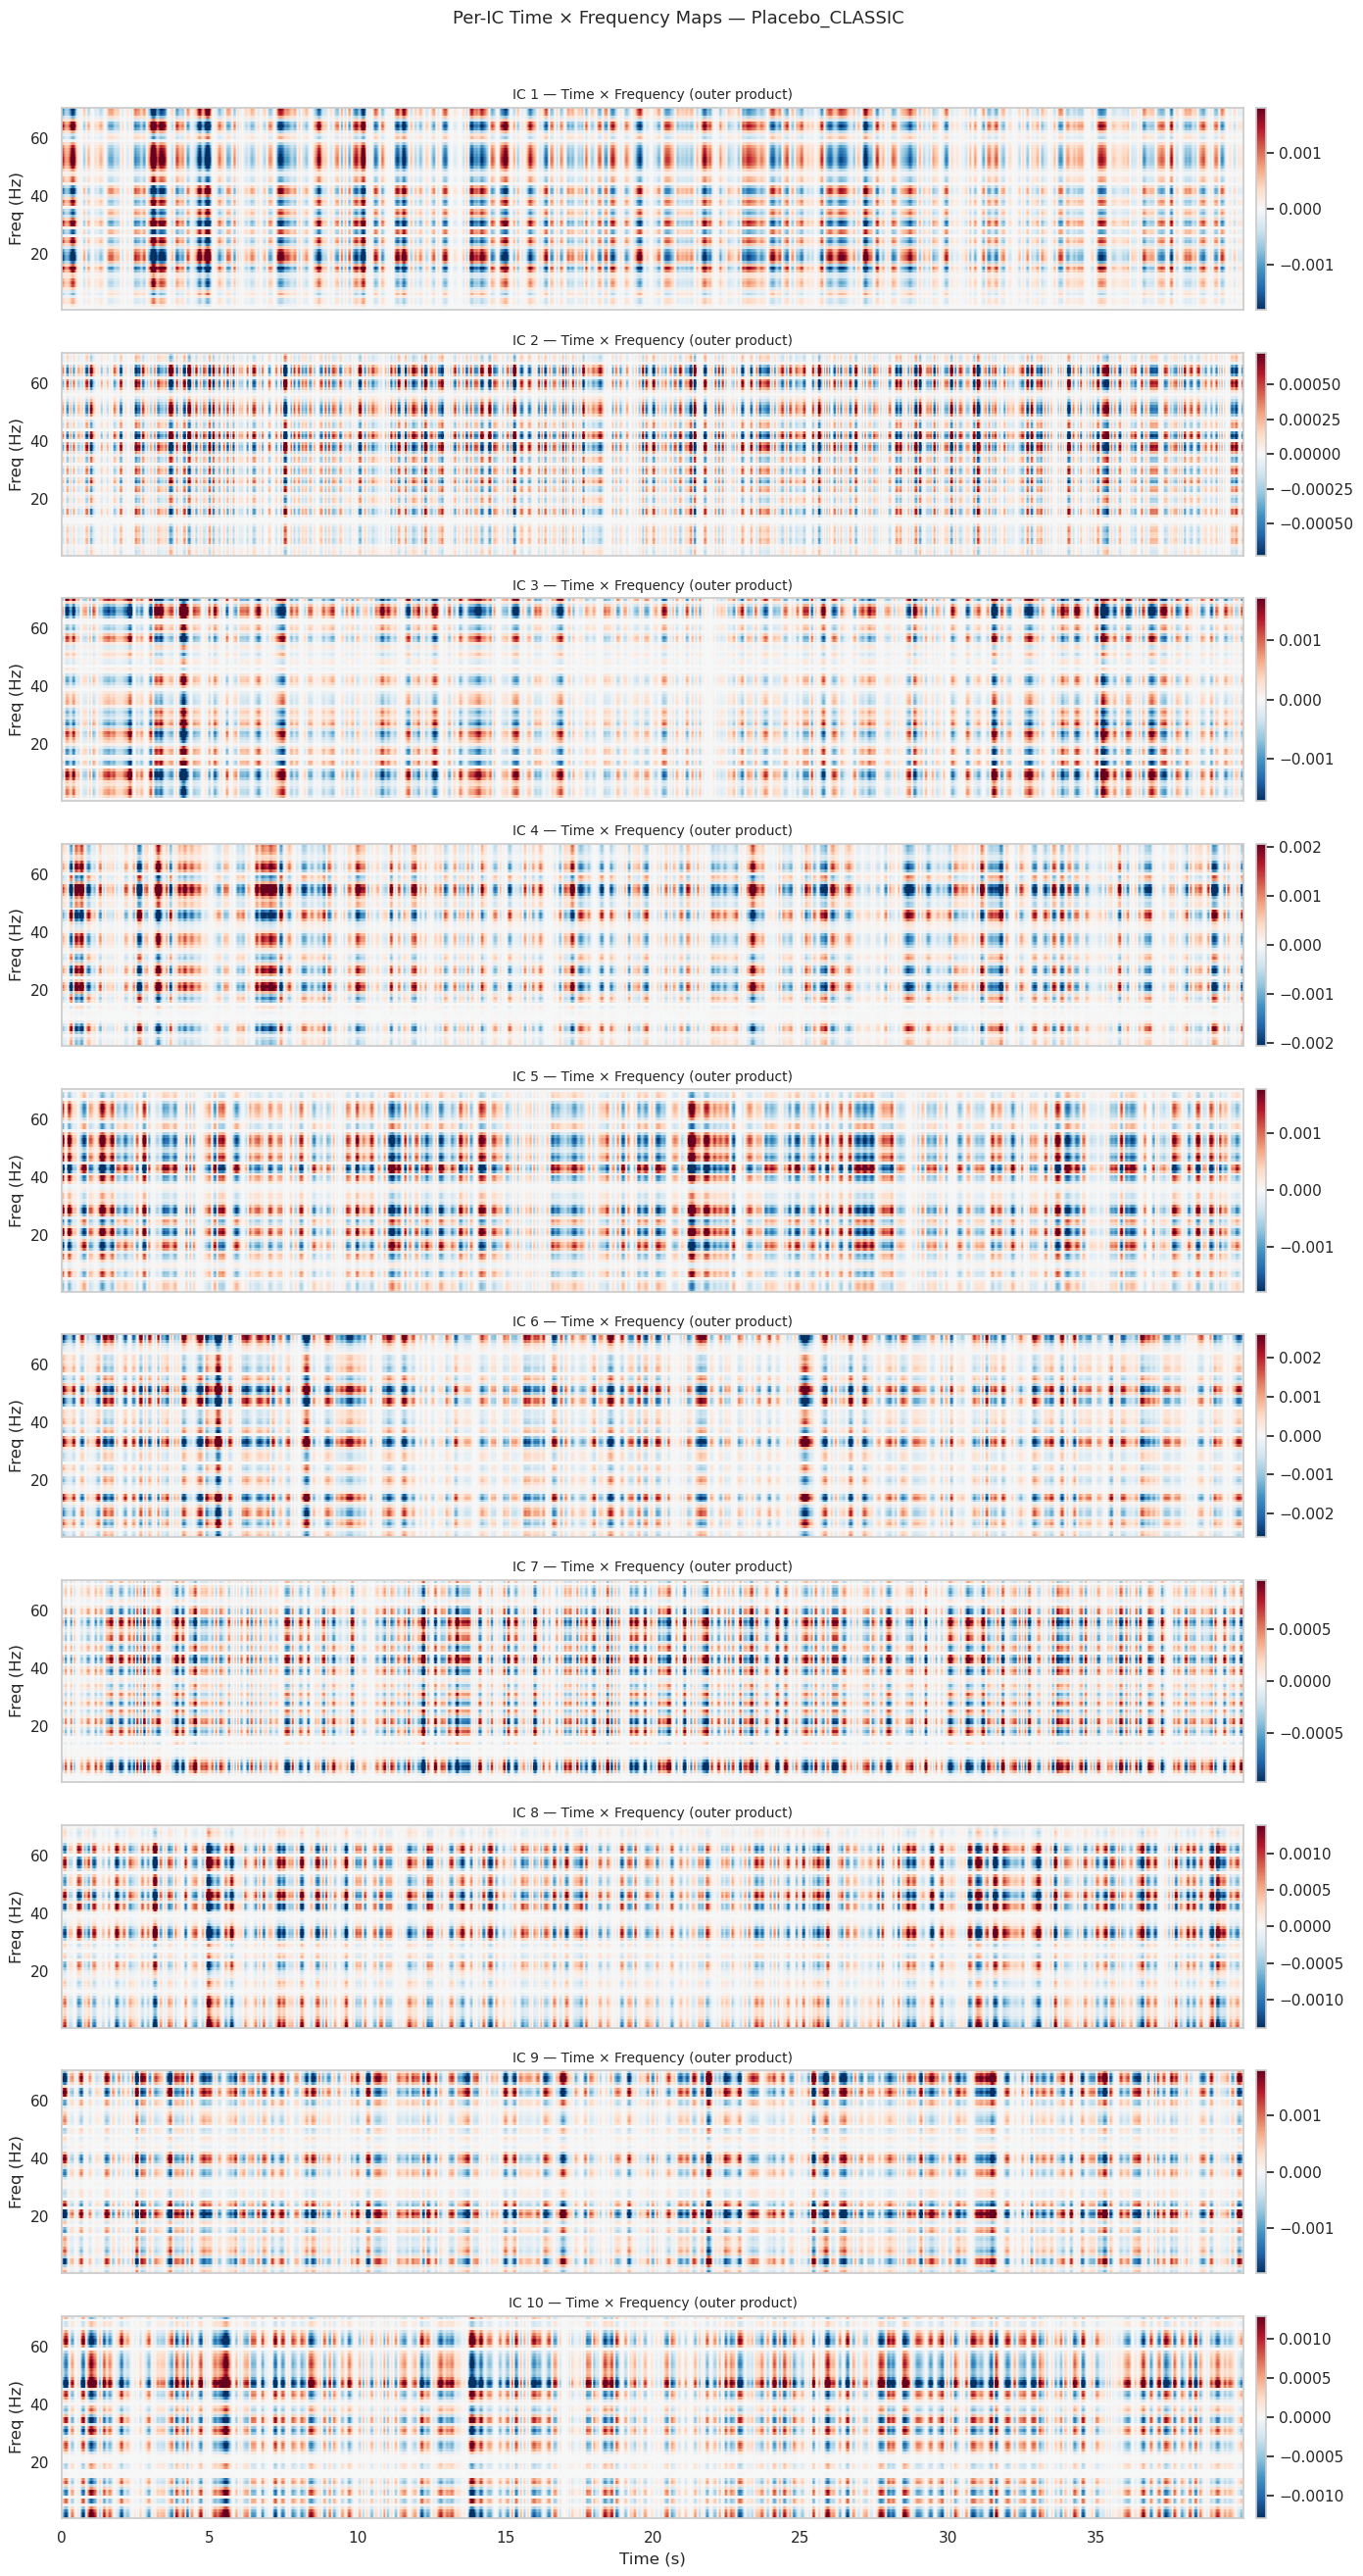

In [15]:
# Subject-averaged spatial-spectral pattern: (N_PCA, F, C)
mean_components = iva_components.mean(axis=0)
# Channel-averaged frequency profile transposed to (F, N_PCA) for einsum
freq_profiles = mean_components.mean(axis=2).T  # (F, N_PCA)
# Subject-averaged source timecourse: (N_PCA, T)
time_profiles = iva_sources_pca.mean(axis=0)

# Outer product per component → (N_PCA, F, T)
ft_maps = np.einsum("fk,kt->kft", freq_profiles, time_profiles)

n_show = N_COMPONENTS_SHOW
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.6 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    data_i = ft_maps[i]  # (F, T)
    vlim_i = np.percentile(np.abs(data_i), 99)
    mesh = ax.pcolormesh(
        time,
        FREQS,
        data_i,
        cmap="RdBu_r",
        vmin=-vlim_i,
        vmax=vlim_i,
        shading="auto",
    )
    ax.set_ylabel("Freq (Hz)")
    ax.set_title(f"IC {i + 1} — Time × Frequency (outer product)", fontsize=10)
    fig.colorbar(mesh, ax=ax, pad=0.01, fraction=0.025)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Per-IC Time × Frequency Maps — {LABEL}", fontsize=13, y=1.01)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "iva_time_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (g) — Source Timecourses: Mean and Variance Across Subjects

For each IVA component the per-subject source `iva_sources_pca[s, k, :]`
is summarised over the subject axis at every time point:

```
mean_temporal[k, t] = mean over s of iva_sources_pca[s, k, t]    # (K, T)
var_temporal[k, t]  = var  over s of iva_sources_pca[s, k, t]    # (K, T)
std_temporal[k, t]  = sqrt(var_temporal[k, t])                   # (K, T)
```

The **mean** is plotted as a line; the **variance** is shown as an
error-shading band (`mean ± √variance`) around it. Narrow bands mark
moments of cross-subject consensus; wide bands mark idiosyncratic
intervals.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `mean_temporal` | `(N_PCA, T)` | Mean source across subjects |
| `var_temporal` | `(N_PCA, T)` | Variance of source across subjects |
| `std_temporal` | `(N_PCA, T)` | Std (band width) |

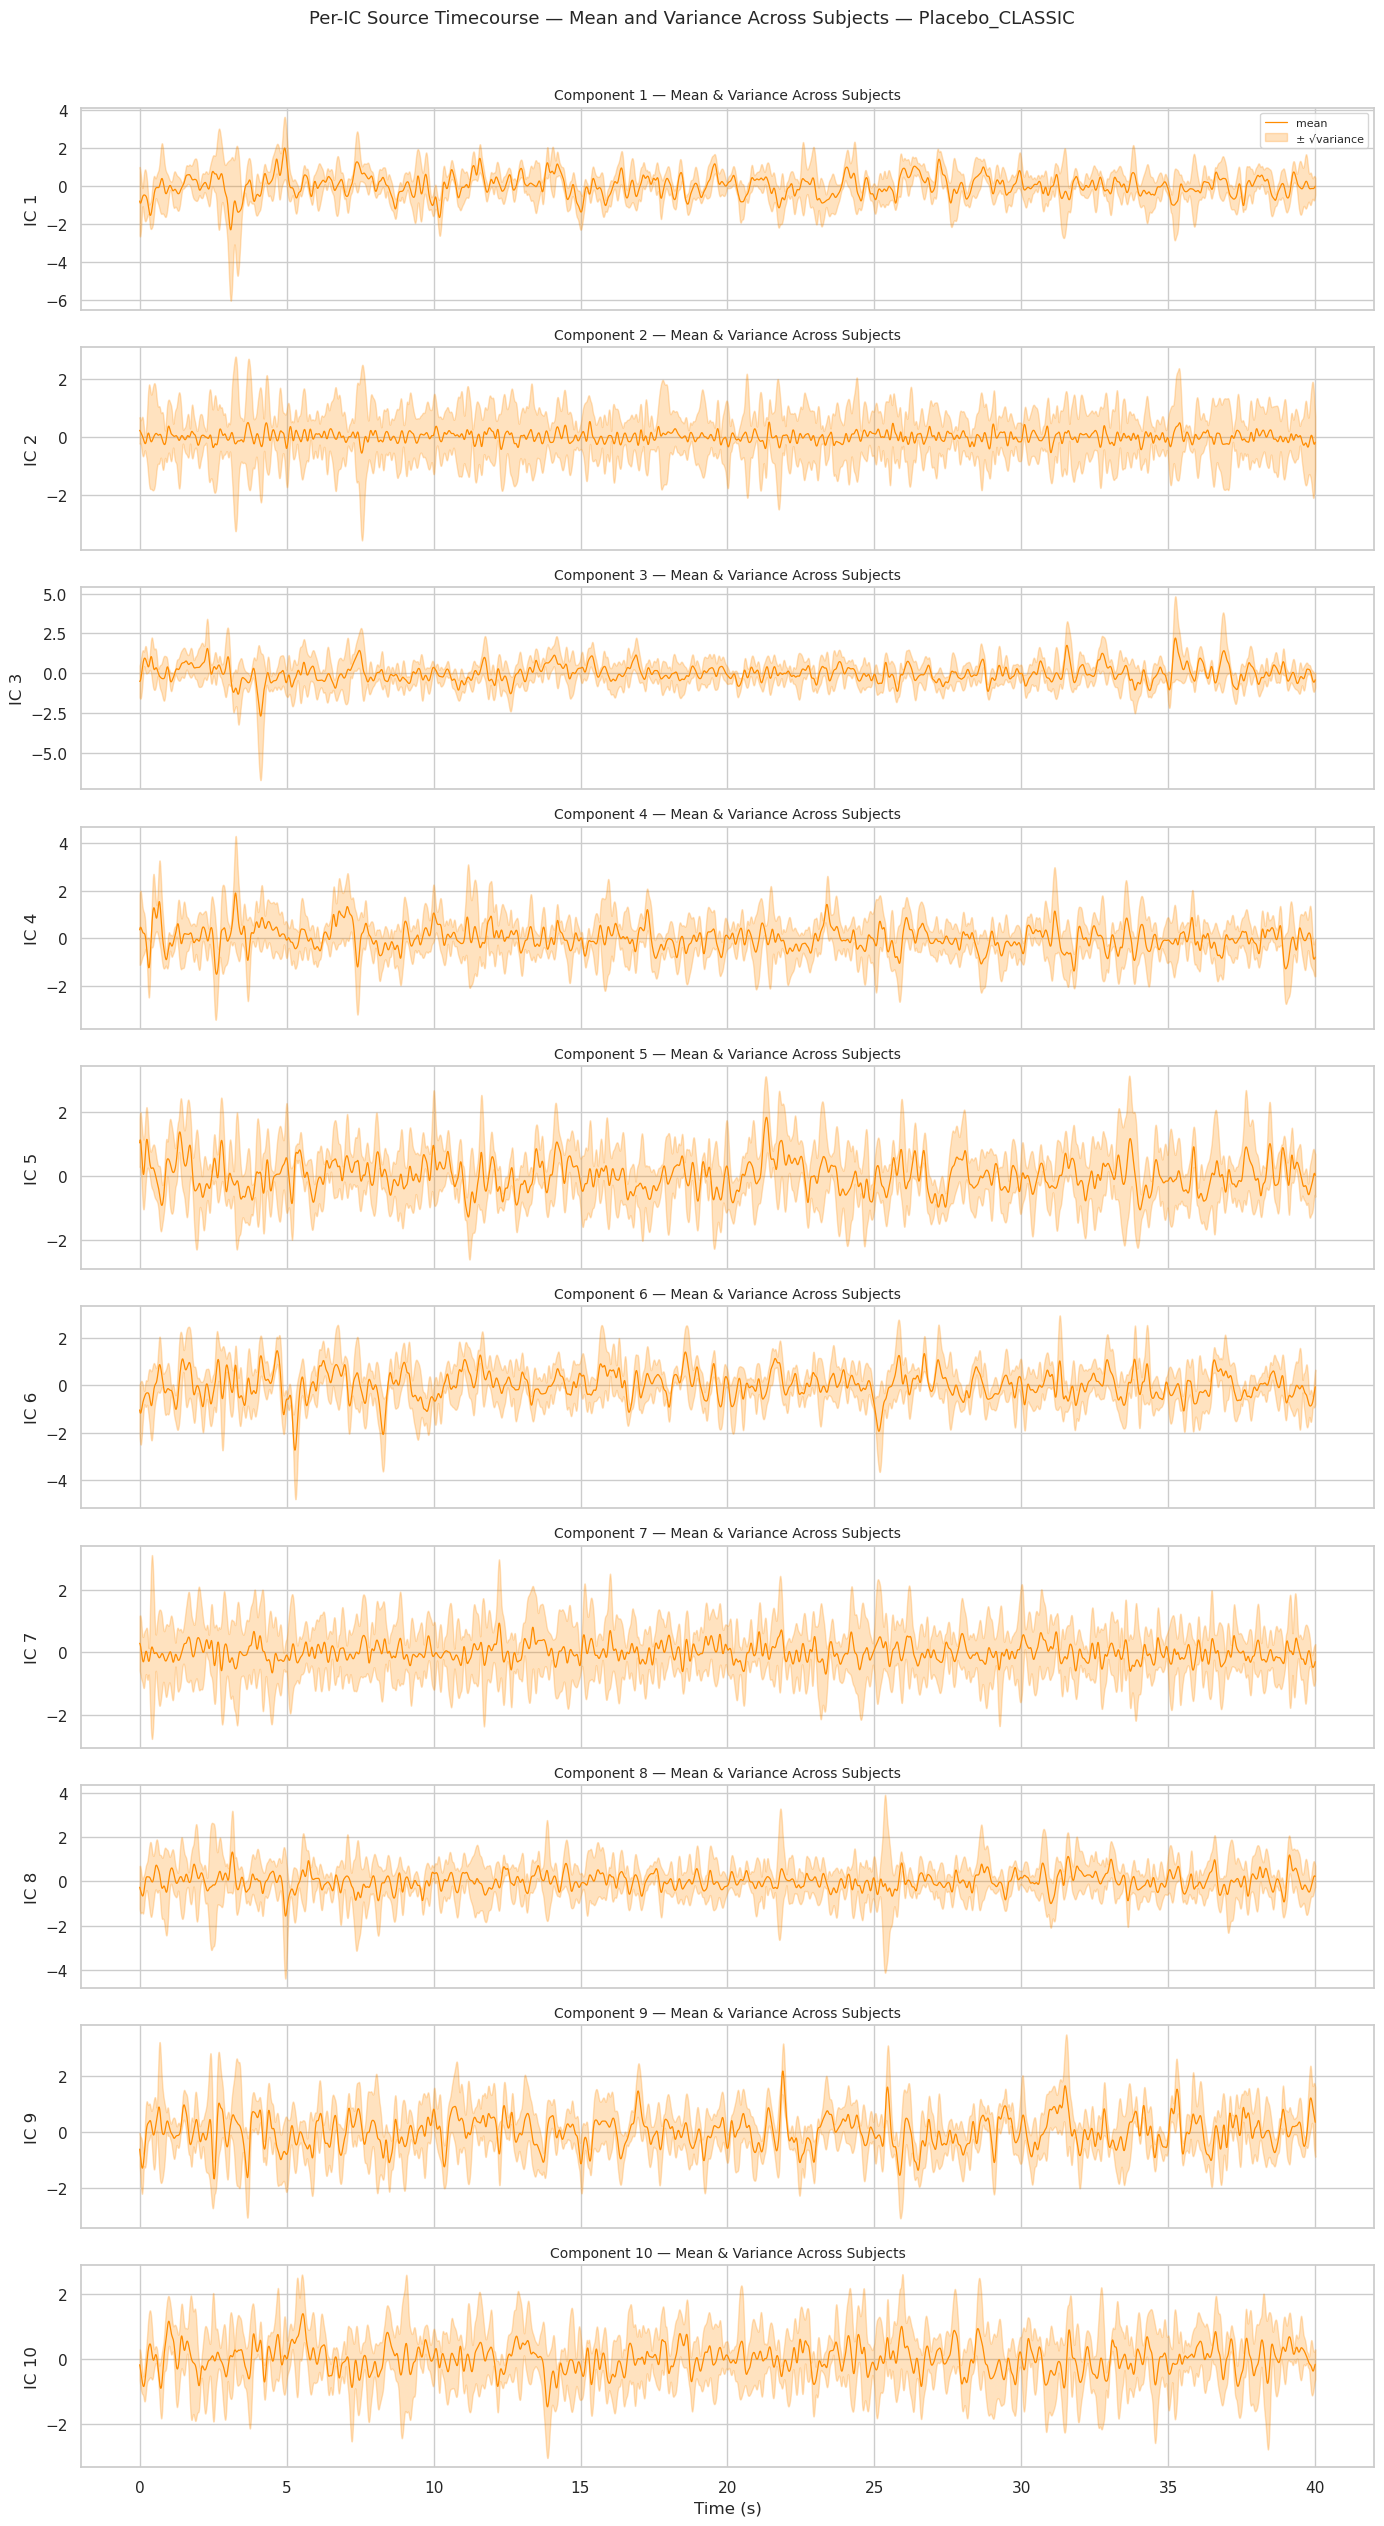

In [16]:
# Across-subject summaries of each IVA source's timecourse
mean_temporal = iva_sources_pca.mean(axis=0)  # (N_PCA, T)
var_temporal = iva_sources_pca.var(axis=0)  # (N_PCA, T)
std_temporal = np.sqrt(var_temporal)  # used as error-band width

n_show = N_COMPONENTS_SHOW
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(time, mean_temporal[i], lw=0.9, color="darkorange", label="mean")
    ax.fill_between(
        time,
        mean_temporal[i] - std_temporal[i],
        mean_temporal[i] + std_temporal[i],
        alpha=0.25,
        color="darkorange",
        label="± √variance",
    )
    ax.set_ylabel(f"IC {i + 1}")
    ax.set_title(f"Component {i + 1} — Mean & Variance Across Subjects", fontsize=10)
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Per-IC Source Timecourse — Mean and Variance Across Subjects — {LABEL}",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "iva_mean_variance_over_time.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()
plt.close("all")